# Анализ данных о пингвинах Палмера (Palmer Penguins)

**Описание проекта:**  
В этом проекте мы проведём полный цикл анализа данных о трёх видах пингвинов с островов Палмера (Антарктика). Мы исследуем данные, визуализируем их, а затем **обучим простую модель машинного обучения** для предсказания вида пингвина по его биометрическим признакам. Финальным этапом станет участие в **Kaggle-соревновании** — мы подготовим предсказания и загрузим их на платформу.

---

## 📋 Оглавление

1. [Загрузка и первичный осмотр](#1-загрузка-и-первичный-осмотр)  
2. [Исследовательский анализ данных (EDA) и группировки](#2-исследовательский-анализ-данных-eda-и-группировки)  
3. [Визуализация](#3-визуализация)  
4. [Обучение модели машинного обучения](#4-обучение-модели-машинного-обучения)  
5. [Подготовка и загрузка предсказаний на Kaggle](#5-подготовка-и-загрузка-предсказаний-на-kaggle)

---

## 📊 Данные

- **Источник:** встроенный датасет `seaborn.load_dataset('penguins')`[reference:0]  
- **Альтернативный источник:** Датасет доступен на Kaggle [по этой ссылке](https://www.kaggle.com/parulpandey/palmer-archipelago-antarctica-penguin-data)[reference:1]  
- **Количество записей:** 344  
- **Признаки:** вид, остров, длина клюва (мм), глубина клюва (мм), длина ласт (мм), масса (г), пол, год.

---

## 🎯 Цели проекта

1. **Изучить данные** — провести первичный анализ, найти пропуски и выбросы.
2. **Визуализировать** — построить графики, чтобы увидеть закономерности.
3. **Построить модель** — обучить классификатор (например, логистическую регрессию или случайный лес) для предсказания вида пингвина[reference:2].
4. **Сделать предсказания** — применить модель к тестовым данным.
5. **Участвовать в Kaggle** — сформировать файл с предсказаниями и загрузить его на платформу[reference:3].

---

*Дата выполнения: 20.06.2026*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Для машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Все библиотеки успешно импортированы!")

✅ Все библиотеки успешно импортированы!


In [3]:
# Загружаем встроенный датасет пингвинов
penguins = pd.read_csv('penguins.csv')

print("=== Размер датасета ===")
print(f"Строк: {penguins.shape[0]}, Столбцов: {penguins.shape[1]}")

print("\n=== Первые 5 строк ===")
display(penguins.head())  # или print(penguins.head())

print("\n=== Информация о колонках и типах данных ===")
print(penguins.info())

print("\n=== Описательная статистика для числовых признаков ===")
display(penguins.describe())

print("\n=== Количество пропусков по каждому столбцу ===")
print(penguins.isnull().sum())

print("\n=== Уникальные значения в категориальных колонках ===")
print("Виды:", penguins['species'].unique())
print("Острова:", penguins['island'].unique())
print("Пол:", penguins['sex'].unique())

=== Размер датасета ===
Строк: 344, Столбцов: 9

=== Первые 5 строк ===


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007



=== Информация о колонках и типах данных ===
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    str    
 2   island             344 non-null    str    
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    str    
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 24.3 KB
None

=== Описательная статистика для числовых признаков ===


,Unnamed: 0,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,342.000000,342.000000,342.000000,342.000000,344.000000
mean,172.500000,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,99.448479,5.459584,1.974793,14.061714,801.954536,0.818356
min,1.000000,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,86.750000,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,172.500000,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,258.250000,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,344.000000,59.600000,21.500000,231.000000,6300.000000,2009.000000



=== Количество пропусков по каждому столбцу ===
Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

=== Уникальные значения в категориальных колонках ===
Виды: <StringArray>
['Adelie', 'Gentoo', 'Chinstrap']
Length: 3, dtype: str
Острова: <StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str
Пол: <StringArray>
['male', 'female', nan]
Length: 3, dtype: str


=== Средние показатели по видам ===
           Unnamed: 0  bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                   
Adelie           76.5       38.791391      18.346358         189.953642   
Chinstrap       310.5       48.833824      18.420588         195.823529   
Gentoo          214.5       47.504878      14.982114         217.186992   

           body_mass_g         year  
species                              
Adelie     3700.662252  2008.013158  
Chinstrap  3733.088235  2007.970588  
Gentoo     5076.016260  2008.080645  

=== Средняя длина клюва по островам и полу ===
island     sex   
Biscoe     female    43.307500
           male      47.119277
Dream      female    42.296721
           male      46.116129
Torgersen  female    37.554167
           male      40.586957
Name: bill_length_mm, dtype: float64

=== Количество особей по полу и виду ===
species    sex   
Adelie     female    73
           male      73
C

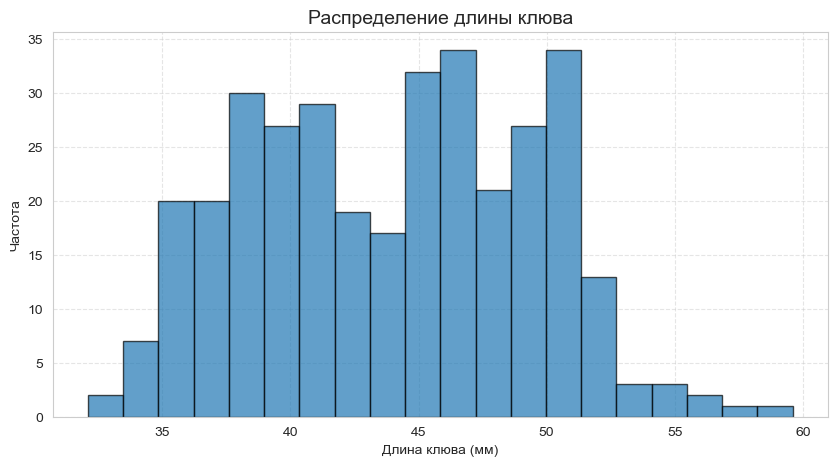

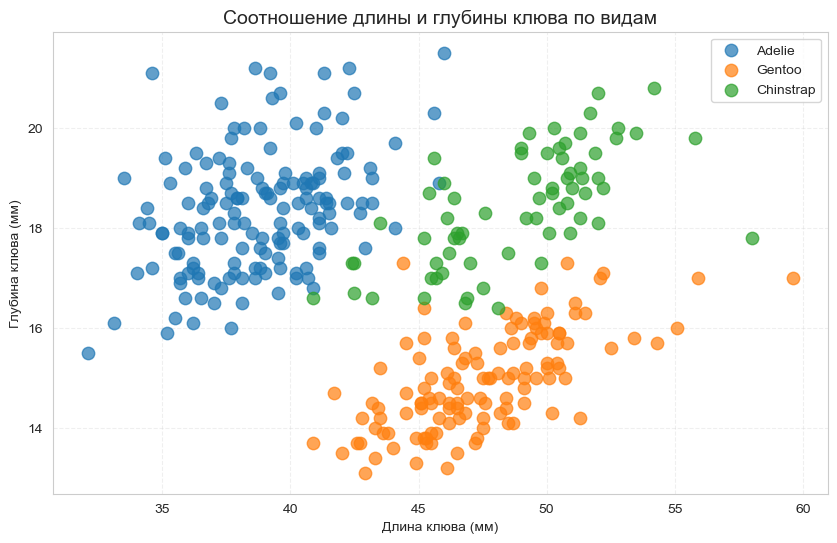

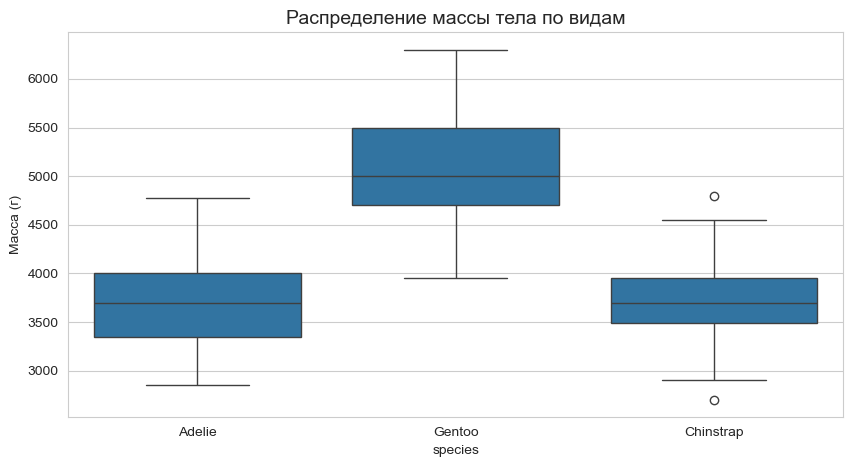

In [4]:
# Средние числовые показатели по видам
print("=== Средние показатели по видам ===")
print(penguins.groupby('species').mean(numeric_only=True))

# Средняя длина клюва по островам и полу
print("\n=== Средняя длина клюва по островам и полу ===")
print(penguins.groupby(['island', 'sex'])['bill_length_mm'].mean())

# Количество пингвинов по полу и виду
print("\n=== Количество особей по полу и виду ===")
print(penguins.groupby(['species', 'sex']).size())

# Гистограмма распределения длины клюва
plt.figure(figsize=(10, 5))
penguins['bill_length_mm'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Распределение длины клюва', fontsize=14)
plt.xlabel('Длина клюва (мм)')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Точечный график: длина vs глубина клюва, цвет по виду
plt.figure(figsize=(10, 6))
for species in penguins['species'].unique():
    subset = penguins[penguins['species'] == species]
    plt.scatter(subset['bill_length_mm'], subset['bill_depth_mm'], 
                label=species, alpha=0.7, s=80)
plt.xlabel('Длина клюва (мм)')
plt.ylabel('Глубина клюва (мм)')
plt.title('Соотношение длины и глубины клюва по видам', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Ящик с усами (boxplot) для массы по видам
plt.figure(figsize=(10, 5))
sns.boxplot(x='species', y='body_mass_g', data=penguins)
plt.title('Распределение массы тела по видам', fontsize=14)
plt.ylabel('Масса (г)')
plt.show()

In [6]:
# Копируем данные, чтобы не испортить исходные
df = penguins.copy()

# Удаляем лишний столбец 'Unnamed: 0' (это просто индекс)
df.drop('Unnamed: 0', axis=1, inplace=True)

# Заполняем числовые пропуски медианой
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Заполняем пропуски в поле 'sex' модой (самое частое значение)
df['sex'].fillna(df['sex'].mode()[0], inplace=True)

# Проверяем, что пропусков больше нет
print("=== Пропуски после обработки ===")
print(df.isnull().sum())

# Кодируем 'species' как целевую переменную (y)
# Используем LabelEncoder для перевода названий видов в числа
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])
# Запоминаем соответствие для обратного преобразования (пригодится позже)
species_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("=== Кодировка видов ===")
print(species_mapping)

# Кодируем 'sex' и 'island' как признаки
df['sex_encoded'] = LabelEncoder().fit_transform(df['sex'])
df['island_encoded'] = LabelEncoder().fit_transform(df['island'])

# Признаки (X) – все числовые и закодированные категориальные, исключаем исходные текстовые и целевую
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
            'sex_encoded', 'island_encoded', 'year']
X = df[features]
y = df['species_encoded']

print("\n=== Форма признаков ===")
print(f"X: {X.shape}, y: {y.shape}")

# Стандартизируем только числовые колонки (не категориальные)
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n=== Размеры выборок ===")
print(f"Обучающая: {X_train.shape[0]}, Тестовая: {X_test.shape[0]}")

# Создаём модель RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучаем
model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred = model.predict(X_test)

# Оценка качества
accuracy = accuracy_score(y_test, y_pred)
print(f"\n=== Точность модели на тестовой выборке: {accuracy:.4f}")

print("\n=== Отчёт о классификации ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Матрица ошибок (для наглядности)
print("\n=== Матрица ошибок ===")
print(confusion_matrix(y_test, y_pred))

importance = pd.DataFrame({
    'Признак': features,
    'Важность': model.feature_importances_
}).sort_values('Важность', ascending=False)
print("\n=== Важность признаков ===")
print(importance)

# ============================================
#ПОДГОТОВКА ПРЕДСКАЗАНИЙ ДЛЯ KAGGLE
# ============================================

# Для Kaggle обычно нужен файл с двумя колонками: id и предсказание.
# Так как у нас нет отдельного тестового файла, мы создадим пример на основе тестовой выборки.
# В реальном соревновании вы бы загрузили test.csv и применили модель.

# Создаём DataFrame с предсказаниями для тестовой выборки
submission = pd.DataFrame({
    'id': range(len(y_test)),  # или можно взять реальные id из тестовых данных
    'species': le.inverse_transform(y_pred)  # переводим числа обратно в названия видов
})

print("\n=== Пример первых 5 предсказаний ===")
print(submission.head())

# Сохраняем в CSV (этот файл можно загрузить на Kaggle)
submission.to_csv('submission.csv', index=False)
print("\n✅ Файл submission.csv сохранён в текущей папке!")

=== Пропуски после обработки ===
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
=== Кодировка видов ===
{'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}

=== Форма признаков ===
X: (344, 7), y: (344,)

=== Размеры выборок ===
Обучающая: 275, Тестовая: 69

=== Точность модели на тестовой выборке: 1.0000

=== Отчёт о классификации ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


=== Матрица ошибок ===
[[30  0  0]
 [ 0 14  0]
 [ 0  0 25]]

=== Важность признаков ===
             

C:\Users\Admin\AppData\Local\Temp\ipykernel_32572\1844067609.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_32572\1844067609.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment